In [1]:
import pandas as pd
import seaborn as sns

### Dataset: Height and Weight (taken from kaggle)

- X = Height (in inches)
- Y = Weight (in pounds)


In [2]:
df = pd.read_csv("data/socr-height-weight.csv")
df_sampled = df.sample(n=100)

In [3]:
df_sampled.head()

,Index,Height(Inches),Weight(Pounds)
7291,7292,70.31945,133.4026
3901,3902,71.08333,130.1898
1002,1003,66.39813,128.3502
117,118,69.76212,136.0632
2400,2401,69.43735,133.5447


In [5]:
x, y = df_sampled["Height(Inches)"], df_sampled["Weight(Pounds)"]

In [6]:
def calc_updated_m_c(x, y, m, c, alpha):
    n = len(x)

    m_gradient = 0.0
    c_gradient = 0.0
    loss = 0.0

    for i in range(n):
        x_i = x.iloc[i]
        y_i = y.iloc[i]

        y_pred_i = (m * x_i) + c

        error_i = y_pred_i - y_i

        loss += error_i**2

        # gradient accumulation
        m_gradient += 2 * x_i * error_i
        c_gradient += 2 * error_i

    loss = loss / n
    m_gradient = m_gradient / n
    c_gradient = c_gradient / n

    updated_m = m - (alpha * m_gradient)
    updated_c = c - (alpha * c_gradient)

    return updated_m, updated_c, loss

In [7]:
def training_loop(x, y, epochs=10, alpha=0.0001):
    m, c = 0, 0

    for e in range(1, epochs + 1):
        m, c, loss = calc_updated_m_c(x, y, m, c, alpha)

        print(f"[Epoch {e}] Error: {loss}; m: {m}; c: {c}")

    return m, c

In [8]:
def plot_results(x, y, m=None, c=None):
    sns.scatterplot(x=x, y=y)

    if m and c:
        y_line = m * x + c
        sns.lineplot(x=x, y=y_line, color="red")

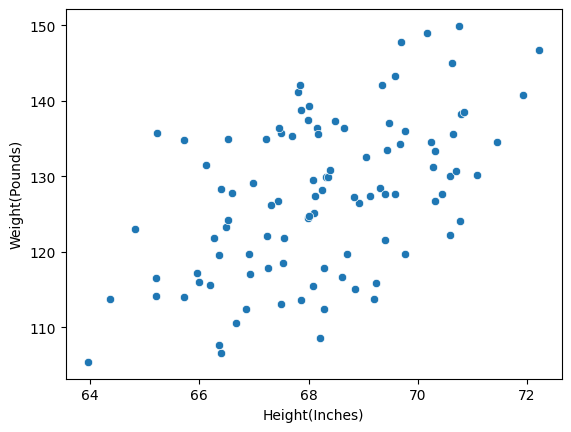

In [9]:
plot_results(x, y)

In [10]:
m, c = training_loop(x, y, epochs=1000)

[Epoch 1] Error: 16320.925184053898; m: 1.7401583528105065; c: 0.0254683038
[Epoch 2] Error: 155.20733978401944; m: 1.8575616483910578; c: 0.027176939275581437
[Epoch 3] Error: 81.6244241577979; m: 1.8654826302185512; c: 0.027282582698524956
[Epoch 4] Error: 81.28948929000246; m: 1.8660171756449702; c: 0.02728007715836768
[Epoch 5] Error: 81.2879636751733; m: 1.8660533808295845; c: 0.027270275140154166
[Epoch 6] Error: 81.28795566845879; m: 1.8660559645243162; c: 0.027259980852172804
[Epoch 7] Error: 81.28795456957448; m: 1.8660562798800786; c: 0.027249653353517783
[Epoch 8] Error: 81.28795350213336; m: 1.8660564421979393; c: 0.02723932361550024
[Epoch 9] Error: 81.28795243483567; m: 1.8660565941907832; c: 0.02722899372765969
[Epoch 10] Error: 81.2879513675389; m: 1.8660567454870112; c: 0.02721866383097096
[Epoch 11] Error: 81.28795030024239; m: 1.8660568967362223; c: 0.02720833393494519
[Epoch 12] Error: 81.2879492329462; m: 1.866057047982243; c: 0.027198004040224065
[Epoch 13] Error:

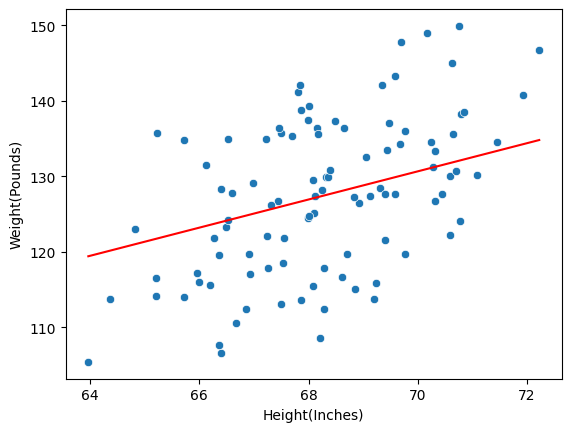

In [11]:
plot_results(x, y, m, c)